In [ ]:
from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/courseproject'
os.chdir(BASE_PATH)

print("Current dir:", os.getcwd())
print("Files:", os.listdir())

Mounted at /content/drive
Current dir: /content/drive/MyDrive/courseproject
Files: ['Screenshot_4.png', 'submissions_archive_2026-04-09.zip', 'user_practice_submissions.csv', 'README.txt', 'micromodules_competencies.csv', 'task_competence_mapping.csv', 'user_competences.csv', 'user_task_submissions.csv']


In [ ]:
tasks = pd.read_csv("user_task_submissions.csv", sep=";")
mapping = pd.read_csv("task_competence_mapping.csv", sep=";")
user_comp = pd.read_csv("user_competences.csv", sep=";")
practice = pd.read_csv("user_practice_submissions.csv", sep=";")
micro = pd.read_csv("micromodules_competencies.csv", sep=";")

In [ ]:
tasks["submission_time"] = pd.to_datetime(tasks["submission_time"], errors="coerce")
practice["submission_time"] = pd.to_datetime(practice["submission_time"], errors="coerce")

In [ ]:
kim_per_user = (
    practice.groupby("user_id", as_index=False)
    .agg(
        kim_count=("practice_submission_id", "nunique")
    )
)
kim_per_user.head(5)

,user_id,kim_count
0,04faac8a-55ba-45e8-b22b-3defa5512390,9
1,0e24ff0e-c58a-4a6c-b054-e80df6607b99,1
2,17993c65-1f0e-4f0a-b458-a7c688b99ea0,19
3,2313e3e0-a834-4dfd-a62e-da6bf6bab116,3
4,363f7164-3a52-43aa-8b9b-b1677ed218ec,17


In [ ]:
tasks_with_kim = tasks.merge(
    practice[["user_id", "practice_submission_id"]],
    on=["user_id", "practice_submission_id"],
    how="inner"
)

kim_results = (
    tasks_with_kim.groupby("user_id", as_index=False)
    .agg(
        kim_tasks=("task_id", "count"),
        kim_accuracy=("is_correct", "mean"),
        kim_avg_score=("score", "mean")
    )
)
kim_results.head(5)

,user_id,kim_tasks,kim_accuracy,kim_avg_score
0,04faac8a-55ba-45e8-b22b-3defa5512390,64,0.953125,0.953125
1,0e24ff0e-c58a-4a6c-b054-e80df6607b99,14,0.785714,1.071429
2,17993c65-1f0e-4f0a-b458-a7c688b99ea0,212,0.622642,0.622642
3,2313e3e0-a834-4dfd-a62e-da6bf6bab116,9,0.222222,0.222222
4,363f7164-3a52-43aa-8b9b-b1677ed218ec,216,0.750000,0.879630


In [ ]:
user_df = kim_per_user.merge(
    kim_results,
    on="user_id",
    how="inner"
)

user_df.head(5)

,user_id,kim_count,kim_tasks,kim_accuracy,kim_avg_score
0,04faac8a-55ba-45e8-b22b-3defa5512390,9,64,0.953125,0.953125
1,0e24ff0e-c58a-4a6c-b054-e80df6607b99,1,14,0.785714,1.071429
2,17993c65-1f0e-4f0a-b458-a7c688b99ea0,19,212,0.622642,0.622642
3,2313e3e0-a834-4dfd-a62e-da6bf6bab116,3,9,0.222222,0.222222
4,363f7164-3a52-43aa-8b9b-b1677ed218ec,17,216,0.750000,0.879630


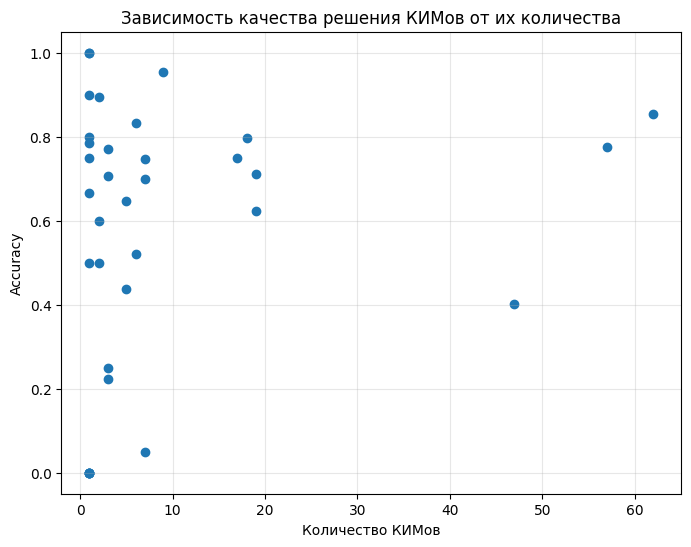

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(user_df["kim_count"], user_df["kim_accuracy"])

plt.title("Зависимость качества решения КИМов от их количества")
plt.xlabel("Количество КИМов")
plt.ylabel("Accuracy")

plt.grid(alpha=0.3)
plt.show()

In [ ]:
corr = user_df[["kim_count", "kim_accuracy"]].corr().iloc[0, 1]
print("Correlation:", corr)

Correlation: 0.1915227355062743


In [ ]:
user_df["kim_group"] = pd.qcut(user_df["kim_count"], q=4, duplicates="drop")

group_summary = (
    user_df.groupby("kim_group", as_index=False)
    .agg(
        users=("user_id", "nunique"),
        avg_kim_count=("kim_count", "mean"),
        avg_accuracy=("kim_accuracy", "mean")
    )
)

group_summary

/tmp/ipykernel_7837/3220363468.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  user_df.groupby("kim_group", as_index=False)


,kim_group,users,avg_kim_count,avg_accuracy
0,"(0.999, 3.0]",20,1.550000,0.517333
1,"(3.0, 7.0]",7,6.142857,0.562199
2,"(7.0, 62.0]",8,31.000000,0.733556


Я проверял, связано ли количество решённых КИМов с качеством их решения. Для этого я посчитал число КИМов на пользователя и его accuracy по задачам внутри КИМов.
В результате получилась небольшая положительная корреляция (~0,19), а при разбиении пользователей на группы видно, что средний accuracy растёт: примерно с 0,51 у пользователей с 1-3 КИМами до 0,73 у пользователей с 8 и более КИМами.
То есть в среднем более активная работа с КИМами получилось что связана с лучшим результатом, однако эта связь не очень сильная, плюс к этому распределение пользователей по группам неравномерное (20/7/8) и выборка в целом небольшая, поэтому результаты могут быть не на сто процентов точные.